In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from torchvision.datasets import MNIST
import os
import umap

In [3]:

# --- 1. Cargar el Dataset (como en tu prompt) ---
print("Cargando el dataset MNIST...")
DATA_FOLDER = './data'
os.makedirs(DATA_FOLDER, exist_ok=True)

# Cargamos el dataset. No necesitamos transformaciones complejas por ahora.
train_dataset = MNIST(DATA_FOLDER, train=True, download=True)
test_dataset = MNIST(DATA_FOLDER, train=False, download=True)
print("Dataset cargado.")

# --- 2. Preparar los Datos para PCA ---

data_train = train_dataset.data.numpy()
labels_train = train_dataset.targets.numpy()
data_test = test_dataset.data.numpy()
labels_test = test_dataset.targets.numpy()
n_muestras, alto, ancho = data_train.shape
data_train_flat = data_train.reshape(n_muestras, alto * ancho)

# Normalizar los datos:
# PCA es sensible a la escala. Normalizamos los píxeles de 0-255 a 0.0-1.0
data_train_flat_normalized = data_train_flat / 255.0
data_test_flat = data_test.reshape(data_test.shape[0], alto * ancho)
data_test_flat_normalized = data_test_flat / 255.0

Cargando el dataset MNIST...
Dataset cargado.


Calculando PCA (reduciendo de 784 a 2 dimensiones)...
PCA completado.
Generando gráfico de dispersión...


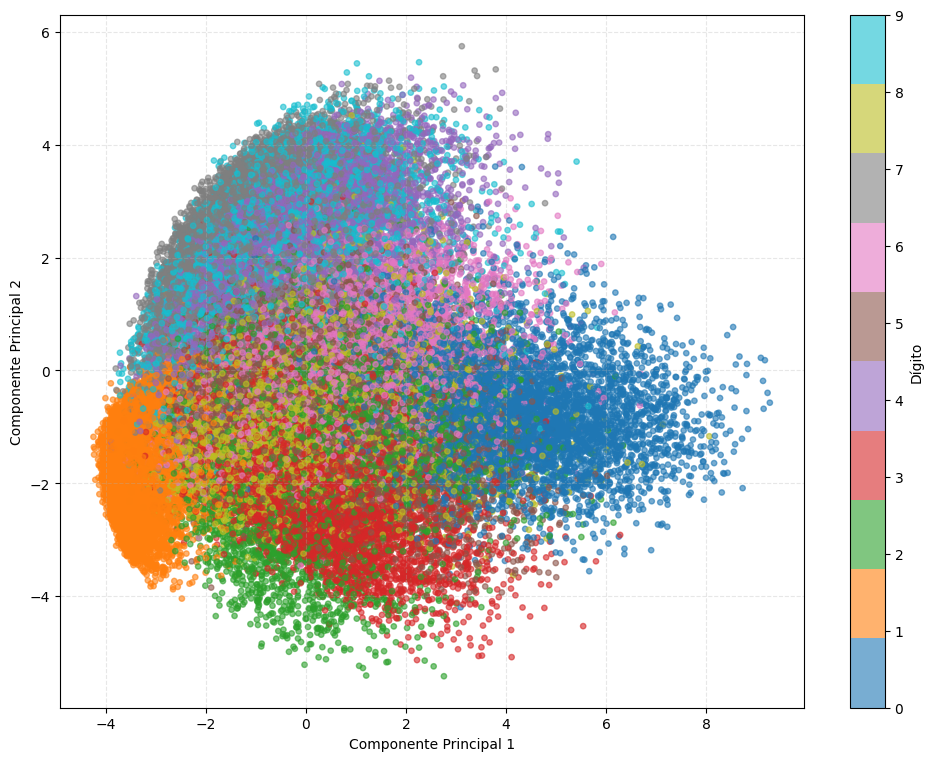

In [17]:

n_muestras, alto, ancho = data_train.shape
data_train_flat = data_train.reshape(n_muestras, alto * ancho)

# Normalizar los datos:
# PCA es sensible a la escala. Normalizamos los píxeles de 0-255 a 0.0-1.0
data_train_flat_normalized = data_train_flat / 255.0

# --- 3. Aplicar PCA ---
print("Calculando PCA (reduciendo de 784 a 2 dimensiones)...")

# Inicializamos PCA pidiendo 2 componentes (dimensiones)
pca = PCA(n_components=2)

# Aplicamos PCA:
# .fit_transform() calcula los componentes y transforma nuestros datos
principal_components = pca.fit_transform(data_train_flat_normalized)

print("PCA completado.")

# principal_components ahora tiene la forma (10000, 2)

# --- 4. Graficar los Puntos ---
print("Generando gráfico de dispersión...")
plt.figure(figsize=(12, 9))

# Creamos un scatter plot (gráfico de dispersión)
# Eje X: Componente Principal 1 (principal_components[:, 0])
# Eje Y: Componente Principal 2 (principal_components[:, 1])
# Color (c): Basado en la etiqueta (labels)
# Colormap (cmap): 'tab10' es excelente para 10 categorías (dígitos 0-9)
scatter = plt.scatter(
    principal_components[:, 0], 
    principal_components[:, 1],
    c=labels_train,                  # Colorear por la etiqueta del dígito
    cmap='tab10',              # Mapa de 10 colores categóricos
    alpha=0.6,                 # Transparencia para ver superposiciones
    s=15                       # Tamaño del punto
)

# Añadir una barra de color (leyenda)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Dígito')

# Añadir títulos y etiquetas
#plt.title(f'Visualización PCA de {len(principal_components)} dígitos MNIST (Entrenamiento)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.3)

# Mostrar el gráfico
plt.show()

# UMAP Train

In [4]:
# --- 3. Aplicar UMAP
print("Calculando UMAP (reduciendo de 784 a 2 dimensiones)...")
print("Esto puede tardar uno o dos minutos...")

# Inicializamos UMAP
# n_neighbors: Controla qué tan "local" vs "global" es la estructura
# min_dist: Controla qué tan "apretados" quedan los clusters
# random_state: Para que el gráfico sea reproducible
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

# Aplicamos UMAP:
# .fit_transform() calcula el "embedding" (la proyección 2D)
embedding = reducer.fit_transform(data_train_flat_normalized)

print("UMAP completado.")
# 'embedding' ahora tiene la forma (15000, 2)

Calculando UMAP (reduciendo de 784 a 2 dimensiones)...
Esto puede tardar uno o dos minutos...


c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP completado.


Generando gráfico de dispersión...


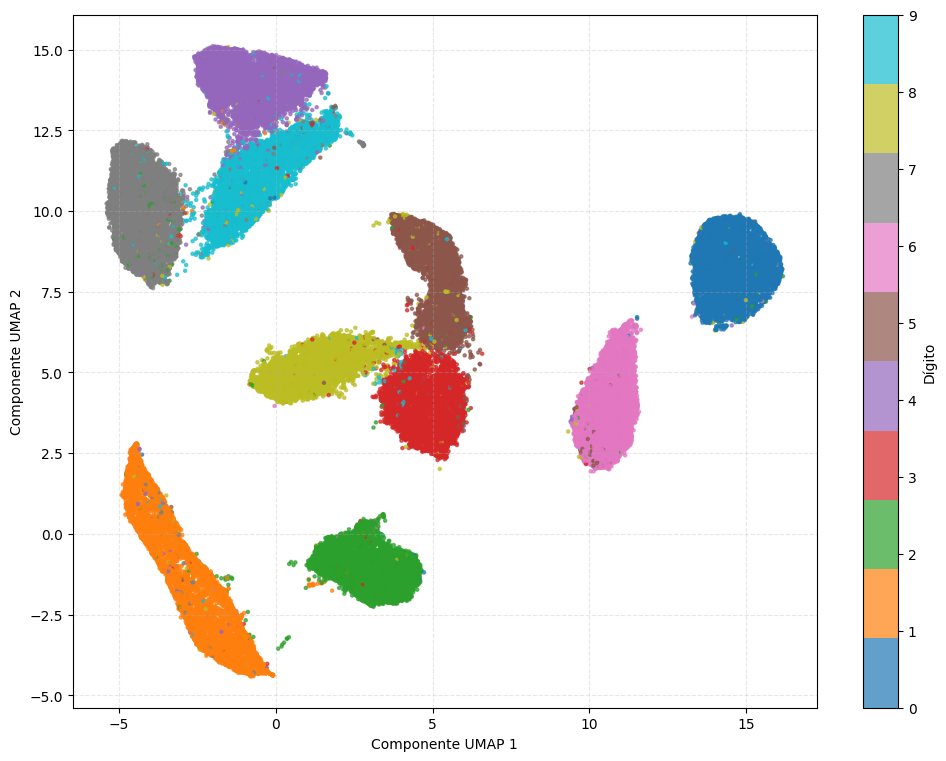

In [5]:
# --- 4. Graficar los Puntos ---
print("Generando gráfico de dispersión...")
plt.figure(figsize=(12, 9))

# Creamos el scatter plot con los resultados de UMAP
scatter = plt.scatter(
    embedding[:, 0],  # Eje X (Componente UMAP 1)
    embedding[:, 1],  # Eje Y (Componente UMAP 2)
    c=labels_train,         # Colorear por la etiqueta del dígito
    cmap='tab10',     # Mapa de 10 colores
    alpha=0.7,        # Transparencia
    s=5               # Puntos más pequeños (UMAP los agrupa bien)
)

# Añadir una barra de color (leyenda)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Dígito')

# Añadir títulos y etiquetas
plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.grid(True, linestyle='--', alpha=0.3)

# Mostrar el gráfico
plt.show()

# UMAP test

Generando gráfico de dispersión...


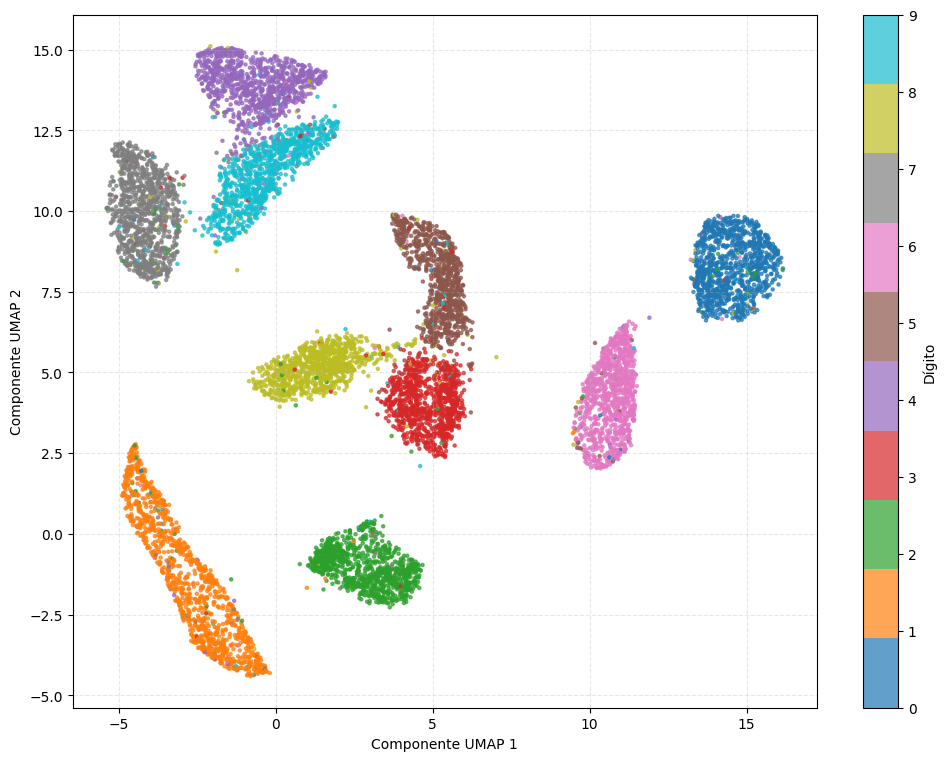

In [6]:
print("Generando gráfico de dispersión...")
plt.figure(figsize=(12, 9))
embedding = reducer.transform(data_test_flat_normalized)
# Creamos el scatter plot con los resultados de UMAP
scatter = plt.scatter(
    embedding[:, 0],  # Eje X (Componente UMAP 1)
    embedding[:, 1],  # Eje Y (Componente UMAP 2)
    c=labels_test,         # Colorear por la etiqueta del dígito
    cmap='tab10',     # Mapa de 10 colores
    alpha=0.7,        # Transparencia
    s=5               # Puntos más pequeños (UMAP los agrupa bien)
)

# Añadir una barra de color (leyenda)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Dígito')

# Añadir títulos y etiquetas
plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.grid(True, linestyle='--', alpha=0.3)

# Mostrar el gráfico
plt.show()